In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPool2D, Rescaling, Flatten
from tensorflow.keras.callbacks import EarlyStopping

2023-12-31 14:18:39.502221: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-31 14:18:39.834871: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2023-12-31 14:18:39.835348: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2023-12-31 14:18:39.841689: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2023-12-31 14:18:39.872798: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2023-12-31 14:18:39.873816: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [4]:
# https://www.cs.toronto.edu/~kriz/cifar.html
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 [==============================] - 13s 0us/step


In [5]:
x_train.shape


(50000, 32, 32, 3)

In [6]:
img_height = 32
img_width = 32
colors = 3

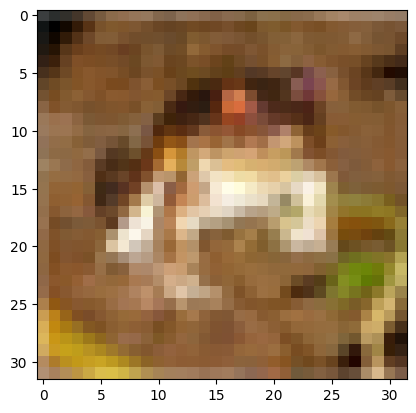

In [7]:
plt.imshow(x_train[0]);

In [8]:
from tensorflow.keras.utils import to_categorical

In [9]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], dtype=uint8)

In [10]:
y_cat_train = to_categorical(y_train)
y_cat_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], dtype=float32)

In [11]:
y_cat_test = to_categorical(y_test)

In [12]:
x_train.max()

255

In [13]:
model = Sequential()

model.add(Rescaling(1.0/255, input_shape=(img_height,img_width,colors)))

model.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
model.add(MaxPool2D())

model.add(Conv2D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPool2D())

model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=10, activation='softmax'))

In [14]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 32, 32, 3)         0         
                                                                 
 conv2d (Conv2D)             (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 15, 15, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 dropout (Dropout)           (None, 6, 6, 64)          0

In [16]:
early_stop = EarlyStopping(monitor='val_loss', patience=3)

In [17]:
model.fit(x=x_train, y=y_cat_train,
          batch_size=64,
          epochs=20,
          callbacks=[early_stop],
          validation_data=(x_test,y_cat_test))

Epoch 1/20


2023-12-31 14:18:59.179701: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 153600000 exceeds 10% of free system memory.


  3/782 [..............................] - ETA: 56s - loss: 2.3115 - accuracy: 0.1198 

2023-12-31 14:19:00.342246: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 19663488 exceeds 10% of free system memory.
2023-12-31 14:19:00.344121: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 19663488 exceeds 10% of free system memory.
2023-12-31 14:19:00.367890: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 14191200 exceeds 10% of free system memory.
2023-12-31 14:19:00.405934: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 19663488 exceeds 10% of free system memory.


782/782 [==============================] - 49s 61ms/step - loss: 1.5017 - accuracy: 0.4597 - val_loss: 1.2742 - val_accuracy: 0.5429
Epoch 2/20
782/782 [==============================] - 44s 56ms/step - loss: 1.1755 - accuracy: 0.5829 - val_loss: 1.0712 - val_accuracy: 0.6279
Epoch 3/20
782/782 [==============================] - 44s 56ms/step - loss: 1.0315 - accuracy: 0.6387 - val_loss: 0.9956 - val_accuracy: 0.6521
Epoch 4/20
782/782 [==============================] - 45s 57ms/step - loss: 0.9478 - accuracy: 0.6684 - val_loss: 0.9114 - val_accuracy: 0.6851
Epoch 5/20
782/782 [==============================] - 44s 56ms/step - loss: 0.8773 - accuracy: 0.6910 - val_loss: 0.8713 - val_accuracy: 0.7025
Epoch 6/20
782/782 [==============================] - 46s 59ms/step - loss: 0.8198 - accuracy: 0.7145 - val_loss: 0.8583 - val_accuracy: 0.7032
Epoch 7/20
782/782 [==============================] - 46s 58ms/step - loss: 0.7671 - accuracy: 0.7317 - val_loss: 0.8344 - val_accuracy: 0.7115
Epo

In [18]:
losses = pd.DataFrame(model.history.history)

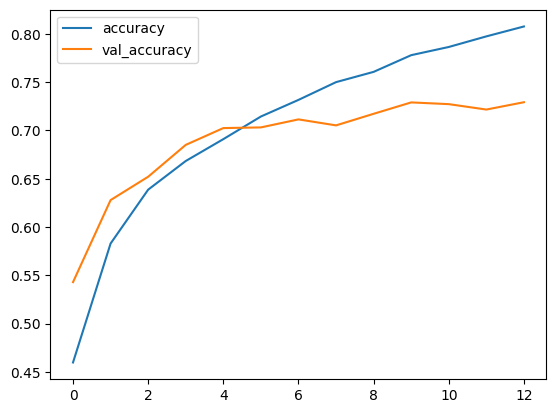

In [19]:
losses[['accuracy','val_accuracy']].plot();

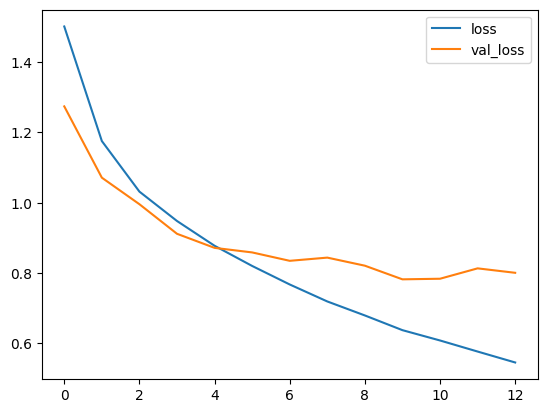

In [20]:
losses[['loss','val_loss']].plot();

In [21]:
model.metrics_names

['loss', 'accuracy']

In [22]:
model.evaluate(x_test, y_cat_test, verbose = 0)

[0.8003159165382385, 0.7293000221252441]

In [23]:
predictions = np.argmax(model.predict(x_test), axis=-1)

313/313 [==============================] - 3s 10ms/step


In [24]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.75      0.79      0.77      1000
           1       0.82      0.87      0.85      1000
           2       0.64      0.59      0.62      1000
           3       0.55      0.52      0.54      1000
           4       0.74      0.65      0.70      1000
           5       0.54      0.69      0.61      1000
           6       0.78      0.81      0.80      1000
           7       0.85      0.72      0.78      1000
           8       0.83      0.85      0.84      1000
           9       0.83      0.79      0.81      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



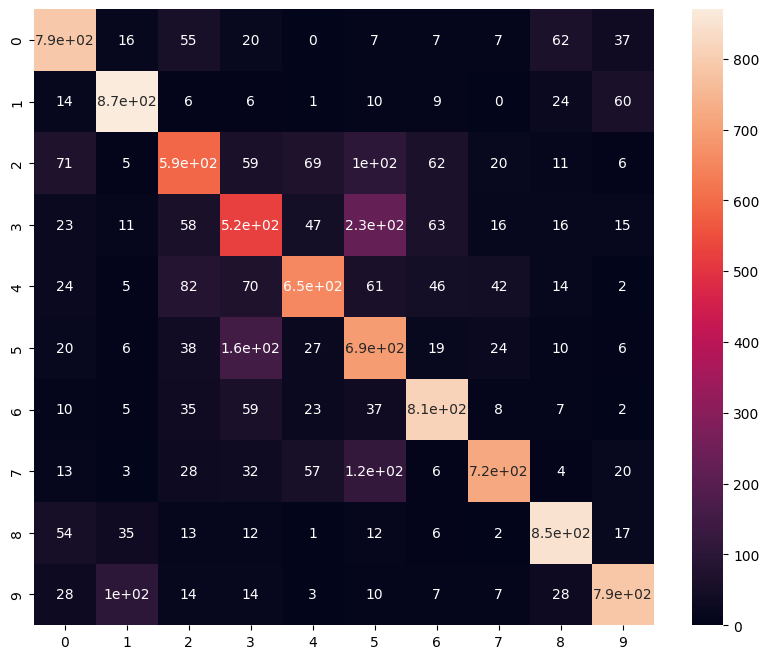

In [25]:
plt.figure(figsize=(10,8))
sns.heatmap(confusion_matrix(y_test,predictions),annot=True);

In [26]:
my_image = x_test[1000]

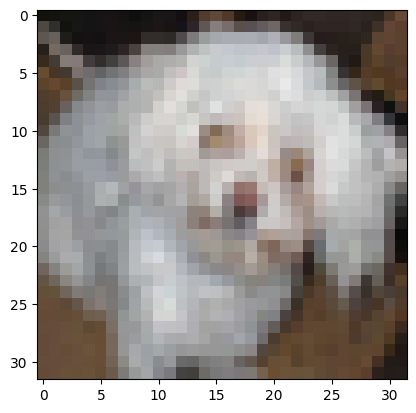

In [27]:
plt.imshow(my_image);

In [28]:
my_image = my_image.reshape(1, img_height, img_width, colors)

In [29]:
prediction = model.predict(my_image)

1/1 [==============================] - 0s 20ms/step


In [30]:
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

In [31]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

print(f'This image belongs to {class_names[predicted_class]} with a {np.floor(confidence*1e4)/100}% of condifence.')

This image belongs to dog with a 99.36% of condifence.
